In [90]:
# Step 0: imports and deterministic seed
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_curve, auc,
                             roc_auc_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# fix random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Iris dataset & quick EDA

In [91]:
iris = datasets.load_iris()
X = iris.data           # features
y = iris.target         # target (0,1,2)
feature_names = iris.feature_names
target_names = iris.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)
print("Target names:", target_names)
print("Class counts:", np.bincount(y))


X shape: (150, 4)
y shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Class counts: [50 50 50]


# Train / test split (80/20) with stratify

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))

Train shapes: (120, 4) (120,)
Test shapes: (30, 4) (30,)
Train class distribution: [40 40 40]
Test class distribution: [10 10 10]


# Preprocessing pipelines & model definitions

In [93]:
pipe_dt = Pipeline([
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])


# Small GridSearchCV for hyperparameters

In [94]:
do_grid = True

best_estimators = {}

if do_grid:
    # Define param grids
    grid_lr = {
        "clf__C": [0.1, 1, 10],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"]
    }
    grid_knn = {
        "clf__n_neighbors": [3, 5, 7, 9]
    }
    grid_dt = {
        "clf__max_depth": [2, 3, 4, None],
        "clf__min_samples_split": [2, 4, 6]
    }

    gs_lr = GridSearchCV(pipe_lr, grid_lr, cv=5, scoring="accuracy", n_jobs=-1)
    gs_lr.fit(X_train, y_train)
    best_estimators['LogisticRegression'] = gs_lr.best_estimator_
    print("LR best params:", gs_lr.best_params_)

    gs_knn = GridSearchCV(pipe_knn, grid_knn, cv=5, scoring="accuracy", n_jobs=-1)
    gs_knn.fit(X_train, y_train)
    best_estimators['KNN'] = gs_knn.best_estimator_
    print("KNN best params:", gs_knn.best_params_)

    gs_dt = GridSearchCV(pipe_dt, grid_dt, cv=5, scoring="accuracy", n_jobs=-1)
    gs_dt.fit(X_train, y_train)
    best_estimators['DecisionTree'] = gs_dt.best_estimator_
    print("DT best params:", gs_dt.best_params_)
else:
    # fallback to default pipelines
    best_estimators['LogisticRegression'] = pipe_lr
    best_estimators['KNN'] = pipe_knn
    best_estimators['DecisionTree'] = pipe_dt


LR best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
KNN best params: {'clf__n_neighbors': 5}
DT best params: {'clf__max_depth': 4, 'clf__min_samples_split': 2}


# Train final models and measure training time

In [95]:
trained = {}
train_times = {}

for name, pipeline in best_estimators.items():
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    t1 = time.time()
    trained[name] = pipeline
    train_times[name] = t1 - t0
    print(f"{name} trained in {train_times[name]:.4f} sec")


LogisticRegression trained in 0.0123 sec
KNN trained in 0.0058 sec
DecisionTree trained in 0.0009 sec


# Predictions, probabilities, and basic metrics

In [96]:
results = []

for name, model in trained.items():
    y_pred = model.predict(X_test)
  
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
    else:
        if hasattr(model, "decision_function"):
            df = model.decision_function(X_test)
            # softmax to convert to pseudo-proba (only if multi-class)
            exps = np.exp(df - np.max(df, axis=1, keepdims=True))
            y_proba = exps / np.sum(exps, axis=1, keepdims=True)
        else:
            y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"\nModel: {name}")
    print("Accuracy:", acc)
    print("Precision (macro):", prec)
    print("Recall (macro):", rec)
    print("F1 (macro):", f1)
    print("Classification report:\n", classification_report(y_test, y_pred, target_names=target_names))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix:\n", cm)

    results.append({
        "model": name,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "y_proba": y_proba
    })


Model: LogisticRegression
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 (macro): 1.0
Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Model: KNN
Accuracy: 0.9333333333333333
Precision (macro): 0.9444444444444445
Recall (macro): 0.9333333333333332
F1 (macro): 0.9326599326599326
Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        3

# Plot confusion matrix heatmap (one per model)

/tmp/ipykernel_18169/2453782973.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


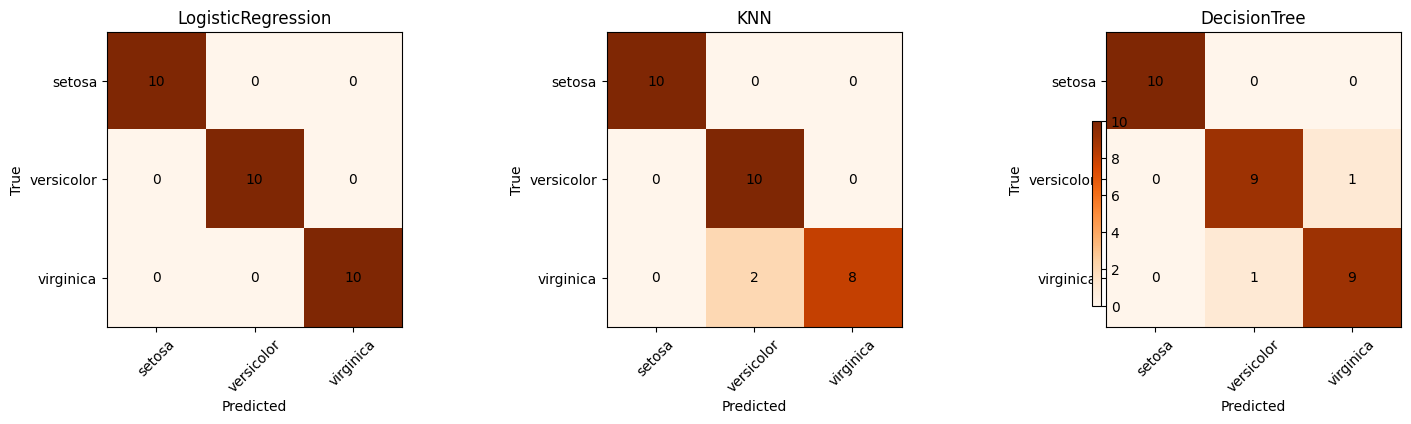

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

for ax, r in zip(axes, results):
    name = r["model"]
    y_pred = trained[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
    ax.set_title(f'{name}')
    tick_marks = np.arange(len(target_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(target_names, rotation=45)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(target_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    # Add counts inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center", color="black")

# Add a single colorbar for all subplots
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.tight_layout()
plt.show()

# ROC curves & AUC (multiclass, One-vs-Rest)

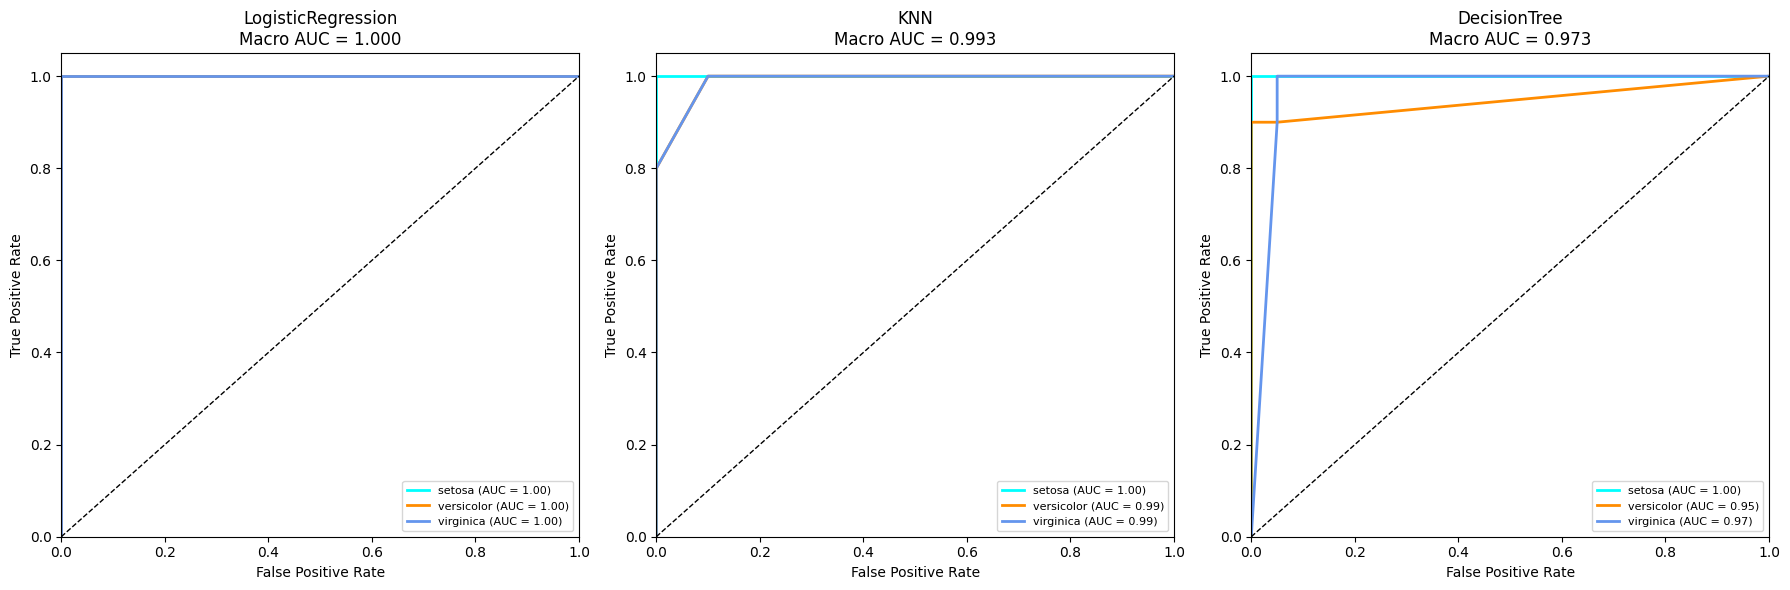

Macro AUCs: {'LogisticRegression': np.float64(1.0), 'KNN': np.float64(0.9933333333333333), 'DecisionTree': np.float64(0.9733333333333333)}


In [98]:
classes = np.unique(y)
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

summary_auc = {}

# Create subplots dynamically (1 row, n columns)
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))  # 6" width per plot

# If there’s only one model, make sure axes is iterable
if n_models == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    name = r["model"]
    y_proba = r["y_proba"]

    if y_proba is None:
        print(f"Model {name} has no probability estimates; skipping ROC.")
        continue

    # Compute ROC curve and AUC for each class
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute macro-average AUC
    macro_auc = np.mean(list(roc_auc.values()))
    summary_auc[name] = macro_auc

    # Plot per model: 3 class curves on one axis
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    for i, color in zip(range(n_classes), colors):
        ax.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2,
            label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})'
        )

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name}\nMacro AUC = {macro_auc:.3f}')
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

print("Macro AUCs:", summary_auc)

# Summary results table and times

In [99]:
summary_rows = []
for r in results:
    name = r["model"]
    summary_rows.append({
        "Model": name,
        "Accuracy": r["accuracy"],
        "Precision_macro": r["precision_macro"],
        "Recall_macro": r["recall_macro"],
        "F1_macro": r["f1_macro"],
        "AUC_macro": summary_auc.get(name, np.nan),
        "Train_time_sec": train_times.get(name, np.nan)
    })

df_summary = pd.DataFrame(summary_rows).set_index("Model")
display(df_summary)  # in notebook; otherwise: print(df_summary)


,Accuracy,Precision_macro,Recall_macro,F1_macro,AUC_macro,Train_time_sec
Model,,,,,,
LogisticRegression,1.000000,1.000000,1.000000,1.000000,1.000000,0.012346
KNN,0.933333,0.944444,0.933333,0.932660,0.993333,0.005763
DecisionTree,0.933333,0.933333,0.933333,0.933333,0.973333,0.000937
